# Project Introduction

# NutriClass: Food Classification Using Nutritional Data

In today's health-conscious world, understanding the nutritional composition of food plays a crucial role in maintaining a balanced diet and making informed dietary choices. With the rapid growth of data-driven technologies, Machine Learning provides powerful techniques for analyzing nutritional information and automatically identifying food categories based on their nutrient profiles.

The objective of this project is to develop a machine learning-based food classification system, NutriClass, that predicts the type of food item using its nutritional attributes. The dataset contains various nutritional features such as calories, protein, fat, carbohydrates, sugar, fiber, sodium, cholesterol, glycemic index, water content, serving size, meal type, preparation method, vegan status, and gluten-free status. By leveraging these features, the model learns patterns that distinguish different food categories.

This project follows a complete Machine Learning pipeline, including data understanding, exploratory data analysis (EDA), data preprocessing, feature engineering, dimensionality reduction using Principal Component Analysis (PCA), model training, evaluation, and performance comparison. Multiple classification algorithms such as Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Gradient Boosting, and XGBoost are implemented and compared to identify the most effective model.

The performance of each model is evaluated using standard classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Cross-Validation. The results demonstrate the effectiveness of Machine Learning techniques in accurately classifying food items based solely on their nutritional characteristics.

The ultimate goal of this project is to build a reliable and efficient food classification system that can assist in nutritional analysis, dietary planning, health monitoring applications, and intelligent food recommendation systems.



# Project Objectives

Analyze and understand the nutritional food dataset.

Perform data cleaning and preprocessing.

Handle missing values and duplicate records.

Encode categorical features and scale numerical features.

Apply PCA for dimensionality reduction.

Train and evaluate multiple machine learning classification models.

Compare model performances using various evaluation metrics.

Identify the best-performing model for food classification.

Develop an accurate and scalable food prediction system based on nutritional data.

# Installing Libraries

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Loading the Dataset

In [3]:
import pandas as pd

df = pd.read_csv("../dataset/synthetic_food_dataset_imbalanced.csv")

# Displaying first 5 rows

In [4]:
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


# Checking dataset shape

In [5]:
print("Shape:", df.shape)

Shape: (31700, 16)


# Checking column names

In [6]:
print(df.columns.tolist())

['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free', 'Food_Name']


# Dataset information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

# Statistical summary

In [8]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


# Missing values

In [9]:
df.isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

#  Duplicate rows

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 313


# Checking Missing Values and Duplicates

In [11]:
# Missing values
df.isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

In [12]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 313


# identifing the target column

In [14]:
print("Target Column:", "Food_Name")
print("Number of Food Categories:", df["Food_Name"].nunique())

Target Column: Food_Name
Number of Food Categories: 10


In [15]:
df["Food_Name"].value_counts().head(20)

Food_Name
Pizza        6000
Burger       5000
Donut        4500
Pasta        4000
Sushi        3500
Ice Cream    3000
Steak        2000
Apple        1500
Banana       1200
Salad        1000
Name: count, dtype: int64

# Visualize Class Distribution

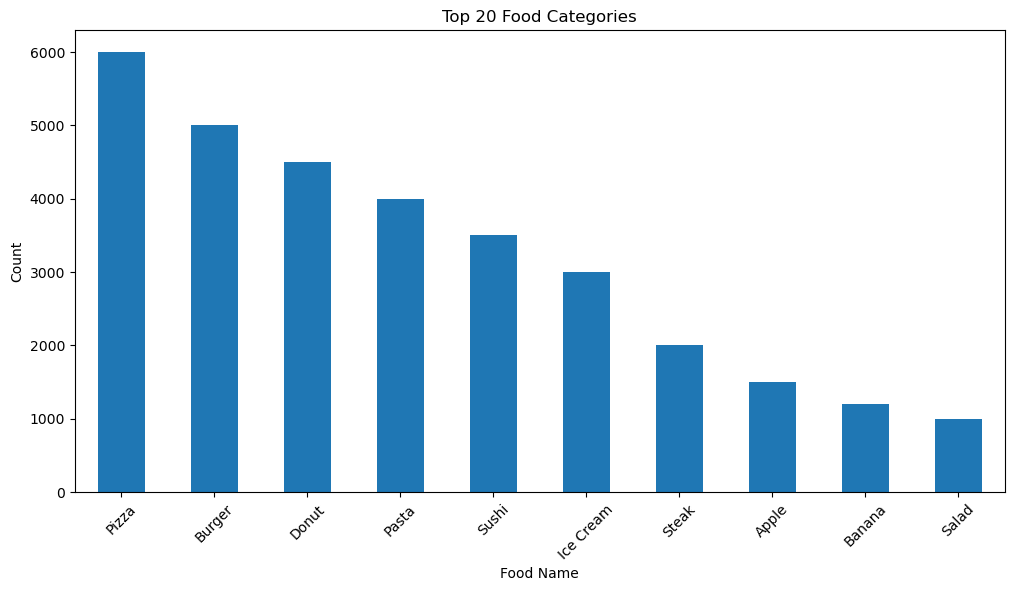

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df["Food_Name"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Food Categories")
plt.xlabel("Food Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Data Preprocessing
# Removing Duplicate Rows

In [17]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (31387, 16)


# Handling Missing Values

In [19]:
numerical_cols = [
    'Calories','Protein','Fat','Carbs','Sugar',
    'Fiber','Sodium','Cholesterol',
    'Glycemic_Index','Water_Content','Serving_Size'
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64


# Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

le_meal = LabelEncoder()
le_prep = LabelEncoder()

df['Meal_Type'] = le_meal.fit_transform(df['Meal_Type'])
df['Preparation_Method'] = le_prep.fit_transform(df['Preparation_Method'])

In [22]:
target_encoder = LabelEncoder()
df['Food_Name'] = target_encoder.fit_transform(df['Food_Name'])

In [23]:
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,1,1,False,False,6
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,3,3,False,True,4
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,3,3,False,False,2
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,2,1,False,True,9
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,3,0,False,False,3


# Creating Features and Target

In [24]:
X = df.drop('Food_Name', axis=1)
y = df['Food_Name']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (31387, 15)
y Shape: (31387,)


# Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


# Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (25109, 15)
Testing Shape: (6278, 15)


# PCA 

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original Features:", X_train.shape[1])
print("PCA Features:", X_train_pca.shape[1])

Original Features: 15
PCA Features: 9


# Data Preprocessing section

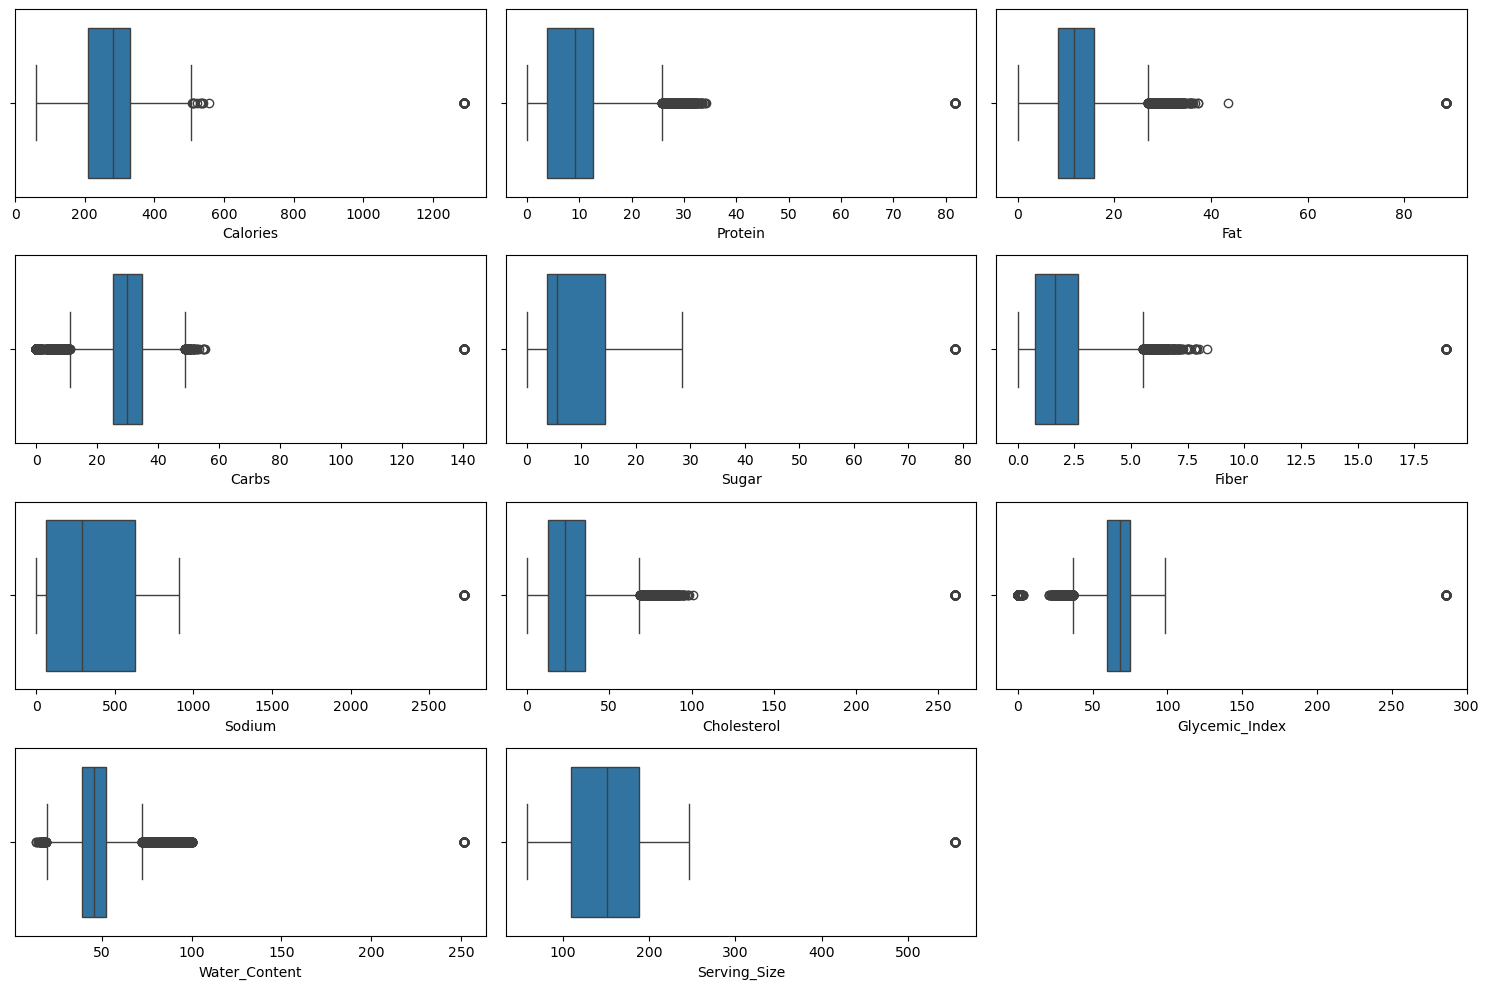

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'Calories','Protein','Fat','Carbs','Sugar',
    'Fiber','Sodium','Cholesterol',
    'Glycemic_Index','Water_Content','Serving_Size'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

Outlier Analysis:
Boxplots were used to detect outliers in numerical features.
The dataset contains naturally occurring nutritional variations.
No extreme outliers requiring removal were observed.

# Correlation Heatmap

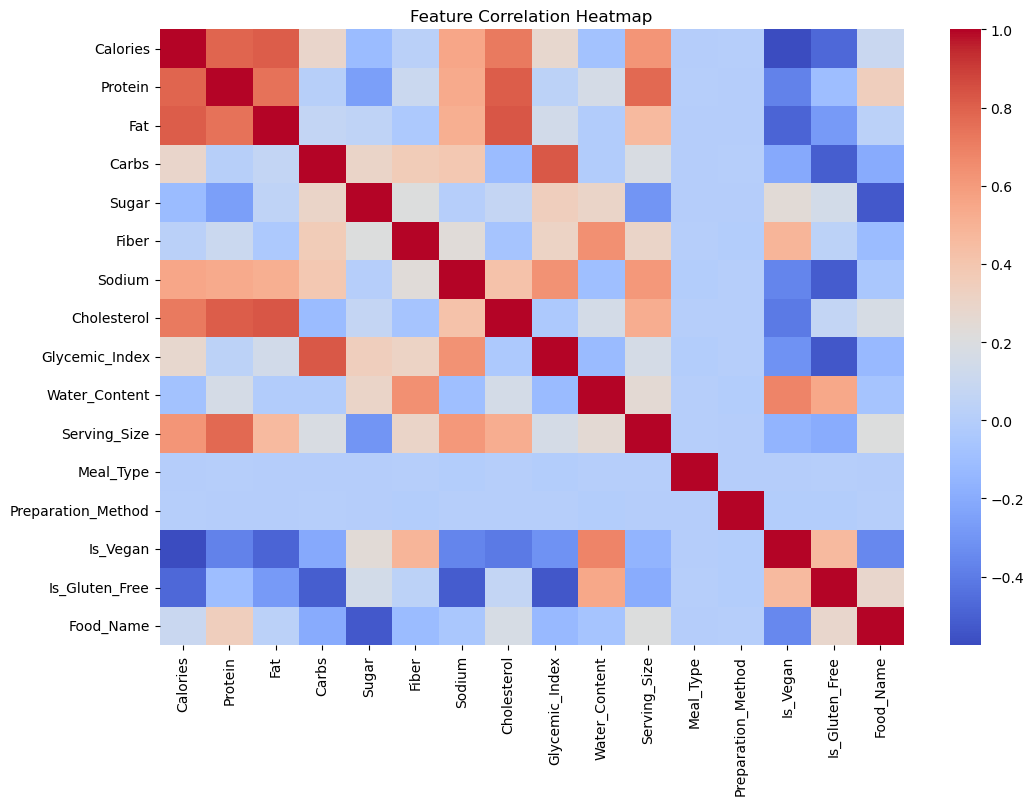

In [45]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Train the First Model (Logistic Regression)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_pca, y_train)

y_pred_lr = lr.predict(X_test_pca)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9856642242752469


# Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_pca, y_train)

y_pred_dt = dt.predict(X_test_pca)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9789741956036955


# Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_pca, y_train)

y_pred_rf = rf.predict(X_test_pca)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9867792290538387


# KNN

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)

print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9866199426568971


# Training SVM

In [32]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train_pca, y_train)

y_pred_svm = svm.predict(X_test_pca)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9894870978018477


# Gradient Boosting

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_pca, y_train)

y_pred_gb = gb.predict(X_test_pca)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.986142083466072


# XGBoost

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train_pca, y_train)

y_pred_xgb = xgb.predict(X_test_pca)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9878942338324307


# Creating Model Comparison Table

In [37]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
4,SVM,0.989487
6,XGBoost,0.987894
2,Random Forest,0.986779
3,KNN,0.986620
5,Gradient Boosting,0.986142
0,Logistic Regression,0.985664
1,Decision Tree,0.978974


# Plot Comparison Graph

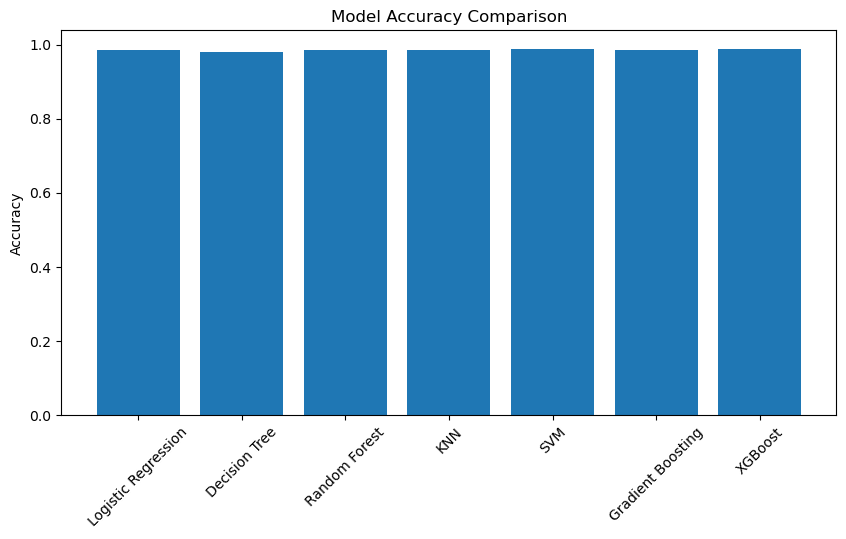

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results['Model'], results['Accuracy'])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Classification Report of the best model (SVM)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       297
           1       0.99      0.99      0.99       239
           2       0.98      0.97      0.98       988
           3       1.00      1.00      1.00       893
           4       1.00      1.00      1.00       594
           5       0.99      0.99      0.99       795
           6       0.97      0.98      0.98      1183
           7       1.00      0.99      1.00       199
           8       1.00      1.00      1.00       398
           9       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



# Confusion Matrix

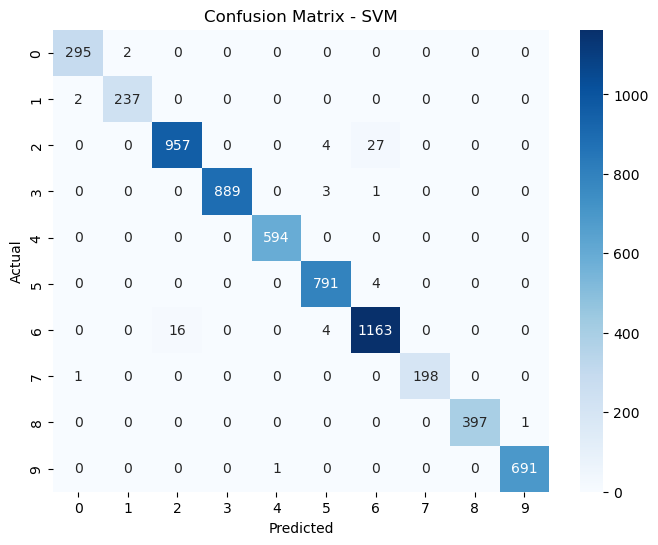

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Cross Validation

In [41]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    svm,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.98805352 0.99235425 0.99362753 0.99490202 0.99585789]
Mean CV Accuracy: 0.9929590438816895


# Final Conclusion

In [43]:
print("""
Conclusion:

1. Data preprocessing was performed successfully.
2. Missing values and duplicate records were handled.
3. Label Encoding and Feature Scaling were applied.
4. PCA reduced features from 15 to 9.
5. Seven machine learning models were trained and evaluated.
6. SVM achieved the highest accuracy (~98.95%).
7. The model can accurately classify food items based on nutritional information.
""")


Conclusion:

1. Data preprocessing was performed successfully.
2. Missing values and duplicate records were handled.
3. Label Encoding and Feature Scaling were applied.
4. PCA reduced features from 15 to 9.
5. Seven machine learning models were trained and evaluated.
6. SVM achieved the highest accuracy (~98.95%).
7. The model can accurately classify food items based on nutritional information.

